# **Cadrage, Ingestion des Données (MASI) et Feature Engineering**

**Contexte du Projet :** Étude comparative entre la simulation de Monte Carlo et le Machine Learning pour le calcul de la Value at Risk (VaR).

**Auteur :** ELMEHDI ES SADIKI

**Institution :** Caisse de Dépôt et de Gestion (CDG) - Digital Factory

---

### **Objectif de ce Notebook**
L'objectif de ce premier notebook est de préparer le socle de données nécessaire aux modèles de risque. Contrairement aux approches théoriques sur des marchés parfaitement liquides, cette étude se base sur les réalités du marché boursier marocain sur une période de 20 ans (2005-2025).

Les étapes clés réalisées ici sont :
1. **L'ingestion et le nettoyage** de la série temporelle de l'indice MASI (gestion des jours fériés et valeurs manquantes).
2. **La transformation mathématique** des prix en rendements logarithmiques continus.
3. **L'établissement d'une Baseline** (VaR Historique).
4. **Le Feature Engineering**, en créant des variables explicatives temporelles (Lags, volatilité glissante) indispensables pour nourrir l'algorithme d'arbres boostés dans les étapes ultérieures.
5. **Le fractionnement chronologique** du dataset (Train / Validation / Test) en respectant l'ordre temporel pour éviter toute fuite de données (*Data Leakage*).

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration esthétique pour les graphiques
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Désactiver les avertissements d'écrasement de Pandas pour un notebook propre
import warnings
warnings.filterwarnings('ignore')

print("Environnement initialisé avec succès. Prêt pour l'ingestion des données MASI.")

Environnement initialisé avec succès. Prêt pour l'ingestion des données MASI.


### 1. **Ingestion et Audit des Données**

**Source Primaire :** Fichier local `masi_historical.csv` (Investing.com).

**Source de Secours (Fallback) :** API Yahoo Finance (Ticker : `^MASI`).

**Période d'étude :** 01 Janvier 2005 - 31 Décembre 2025.

**Objectif de cette étape :**
Suite à l'instabilité constatée des API publiques sur l'historique des indices africains, l'ingestion des données est restructurée. L'algorithme priorise la lecture d'un fichier plat (CSV) garantissant l'intégrité et la disponibilité de la donnée. En cas d'absence du fichier, le système tente une connexion à l'API de secours.

Le script intègre également des routines de nettoyage à la volée (parsing des dates, suppression des séparateurs de milliers textuels) et un audit rigoureux de la continuité temporelle (détection des jours manquants dus aux jours fériés ou aux arrêts de cotation).

In [2]:
import os
from IPython.display import display

# Configuration des variables globales
csv_file_path = "masi_historique.csv"
ticker = "^MASI"
start_date = "2005-01-01"
end_date = "2025-12-31"

print("Demarrage du module d'ingestion des donnees MASI...")

df_masi = pd.DataFrame()

# ETAPE A : Tentative de chargement du fichier local (Primaire)
if os.path.exists(csv_file_path):
    print(f"Fichier local detecte : {csv_file_path}. Chargement en cours...")
    try:
        # Lecture avec Pandas. L'index doit etre la date.
        df_masi = pd.read_csv(csv_file_path, index_col='Date', parse_dates=True)

        # Standardisation des colonnes (Gestion des exports Francais/Anglais)
        if 'Price' in df_masi.columns:
            df_masi.rename(columns={'Price': 'Close'}, inplace=True)
        elif 'Dernier' in df_masi.columns:
            df_masi.rename(columns={'Dernier': 'Close'}, inplace=True)

        # Nettoyage des separateurs de milliers textuels (ex: "12 345,67" -> 12345.67)
        if 'Close' in df_masi.columns and df_masi['Close'].dtype == 'object':
            df_masi['Close'] = df_masi['Close'].str.replace(' ', '', regex=False)
            df_masi['Close'] = df_masi['Close'].str.replace(',', '', regex=False)
            df_masi['Close'] = df_masi['Close'].astype(float)

        print("Chargement du fichier CSV reussi.")
    except Exception as e:
        print(f"Erreur technique lors de la lecture du fichier CSV : {e}")
        df_masi = pd.DataFrame() # Reinitialisation en cas d'erreur de parsing
else:
    print(f"Alerte : Le fichier {csv_file_path} est introuvable dans le repertoire de travail.")

# ETAPE B : Tentative de telechargement API (Secours)
if df_masi.empty:
    print(f"Basculement sur l'API de secours (Yahoo Finance) pour le ticker {ticker}...")
    df_masi = yf.download(ticker, start=start_date, end=end_date)

    if df_masi.empty:
        print("ERREUR CRITIQUE : Le telechargement via l'API a egalement echoue.")
    else:
        print("Telechargement API reussi.")

# ETAPE C : Audit d'integrite des series temporelles
if not df_masi.empty:
    # Tri chronologique ascendant obligatoire pour les series temporelles
    df_masi = df_masi.sort_index(ascending=True)

    # Extraction de la plage d'etude reelle
    first_date = df_masi.index.min()
    last_date = df_masi.index.max()
    print(f"\nHistorique temporel valide : du {first_date.strftime('%Y-%m-%d')} au {last_date.strftime('%Y-%m-%d')}")

    # Generation d'un calendrier theorique des jours ouvres (Business Days)
    theoretical_dates = pd.date_range(start=first_date, end=last_date, freq='B')
    actual_dates = df_masi.index

    # Calcul des differences ensemblistes
    missing_dates = theoretical_dates.difference(actual_dates)

    print("-" * 60)
    print("RAPPORT D'AUDIT DE LA QUALITE DES DONNEES")
    print("-" * 60)
    print(f"Nombre de jours ouvres theoriques sur la periode : {len(theoretical_dates)}")
    print(f"Nombre de jours reels charges (cotations)        : {len(actual_dates)}")
    print(f"Nombre de jours sans cotation (Trous detectes)   : {len(missing_dates)}")

    # Identification de la colonne cible pour la recherche de NaN
    col_cible = 'Adj Close' if 'Adj Close' in df_masi.columns else 'Close'

    if col_cible in df_masi.columns:
        # Contournement de l'architecture MultiIndex de certaines versions de yfinance
        if isinstance(df_masi[col_cible], pd.DataFrame):
            nan_count = df_masi[col_cible].isna().sum().iloc[0]
        else:
            nan_count = df_masi[col_cible].isna().sum()
        print(f"Nombre de valeurs manquantes (NaN) dans [{col_cible}] : {nan_count}")
    else:
        print(f"Alerte : Colonne de prix {col_cible} introuvable pour la verification des NaN.")

    print("-" * 60)

    # Affichage des 5 premieres lignes pour controle visuel
    display(df_masi)
else:
    print("\nARRET DU SCRIPT : Aucune donnee n'a pu etre chargee. Veuillez verifier le chemin du fichier CSV.")

Demarrage du module d'ingestion des donnees MASI...
Fichier local detecte : masi_historique.csv. Chargement en cours...
Chargement du fichier CSV reussi.

Historique temporel valide : du 2005-01-03 au 2025-01-27
------------------------------------------------------------
RAPPORT D'AUDIT DE LA QUALITE DES DONNEES
------------------------------------------------------------
Nombre de jours ouvres theoriques sur la periode : 5236
Nombre de jours reels charges (cotations)        : 5000
Nombre de jours sans cotation (Trous detectes)   : 236
Nombre de valeurs manquantes (NaN) dans [Close] : 0
------------------------------------------------------------


,Close,Ouv.,Plus Haut,Plus Bas,Vol.,Variation %
Date,,,,,,
2005-01-03,4.52222,"4.522,22","4.522,22","4.522,22",NaN,"0,01%"
2005-01-04,4.49399,"4.520,14","4.520,14","4.477,78",NaN,"-0,62%"
2005-01-05,4.49490,"4.495,78","4.495,78","4.466,68",NaN,"0,02%"
2005-01-06,4.48948,"4.477,15","4.492,15","4.477,08",NaN,"-0,12%"
2005-01-07,4.47650,"4.483,29","4.494,18","4.461,95",NaN,"-0,29%"
...,...,...,...,...,...,...
2025-01-21,15.76892,"15.969,02","16.030,23","15.764,89",NaN,"-1,25%"
2025-01-22,15.77563,"15.768,92","15.819,90","15.706,53",NaN,"0,04%"
2025-01-23,15.82803,"15.775,63","15.876,74","15.763,09",NaN,"0,33%"


### **2. Calcul des Rendements Logarithmiques (Log-Returns)**

**La Transformation Fondamentale :**
En modélisation de risques financiers, qu'il s'agisse de processus stochastiques (Monte Carlo) ou d'arbres de décision (Machine Learning), nous ne modélisons jamais les prix bruts. Une série de prix est non-stationnaire (elle possède une tendance et une variance qui évoluent dans le temps). Nous devons la transformer en une série de rendements.

Dans l'industrie quantitative, nous privilégions les **rendements logarithmiques** (continus) aux rendements simples (discrets).

Soit $P_t$ le prix de l'indice MASI au jour $t$.
* Le rendement simple est défini par : $$R_t = \frac{P_t - P_{t-1}}{P_{t-1}}$$
* Le rendement logarithmique est défini par : $$r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)$$

**Pourquoi cette préférence pour les modèles de VaR ?**

**1. L'Additivité Temporelle (Scalabilité)**
Calculer un rendement simple sur $N$ jours nécessite le calcul d'un produit cumulé : $1 + R_{total} = \prod_{i=1}^{N}(1 + R_i)$.
À l'inverse, grâce aux propriétés de la fonction logarithme, le rendement logarithmique sur $N$ jours est purement additif : $$r_{total} = \sum_{i=1}^{N} r_i$$
Cette propriété est fondamentale pour le Mouvement Brownien Géométrique : elle permet de calculer la trajectoire du prix à n'importe quel horizon temporel par de simples additions matricielles, garantissant des temps de calcul extrêmement réduits.

**2. La Symétrie Mathématique**
Si le marché s'effondre de 100 points à 50 points, le rendement simple est de -50%. Pour revenir à son point de départ (de 50 à 100 points), le rendement simple doit être de +100%. Cette asymétrie fausse l'évaluation du risque de recouvrement.
Avec les rendements continus, la baisse est de $\ln(50/100) \approx -69.31\%$ et la hausse est de $\ln(100/50) \approx +69.31\%$. L'amplitude des chocs est parfaitement symétrique.

**3. Rapprochement avec la Loi Normale**
La composition de mouvements exponentiels symétriques tend vers une distribution normale des rendements, ce qui est l'hypothèse de base (bien qu'imparfaite, d'où l'intervention du Machine Learning) du modèle de Monte Carlo standard.

Calcul des rendements continus en cours...
--------------------------------------------------
STATISTIQUES DES RENDEMENTS LOGARITHMIQUES (MASI)
--------------------------------------------------
Moyenne journaliere (Drift) : 0.000251
Volatilite journaliere      : 0.007700
Asymetrie (Skewness)        : -0.7386
Kurtosis (Queues epaisses)  : 11.4090
--------------------------------------------------
Alerte Quant : Le Kurtosis est tres eleve. Le marche presente des chocs extremes (Fat Tails).
Le Mouvement Brownien standard risque de sous-estimer la VaR. Le Machine Learning sera pertinent.


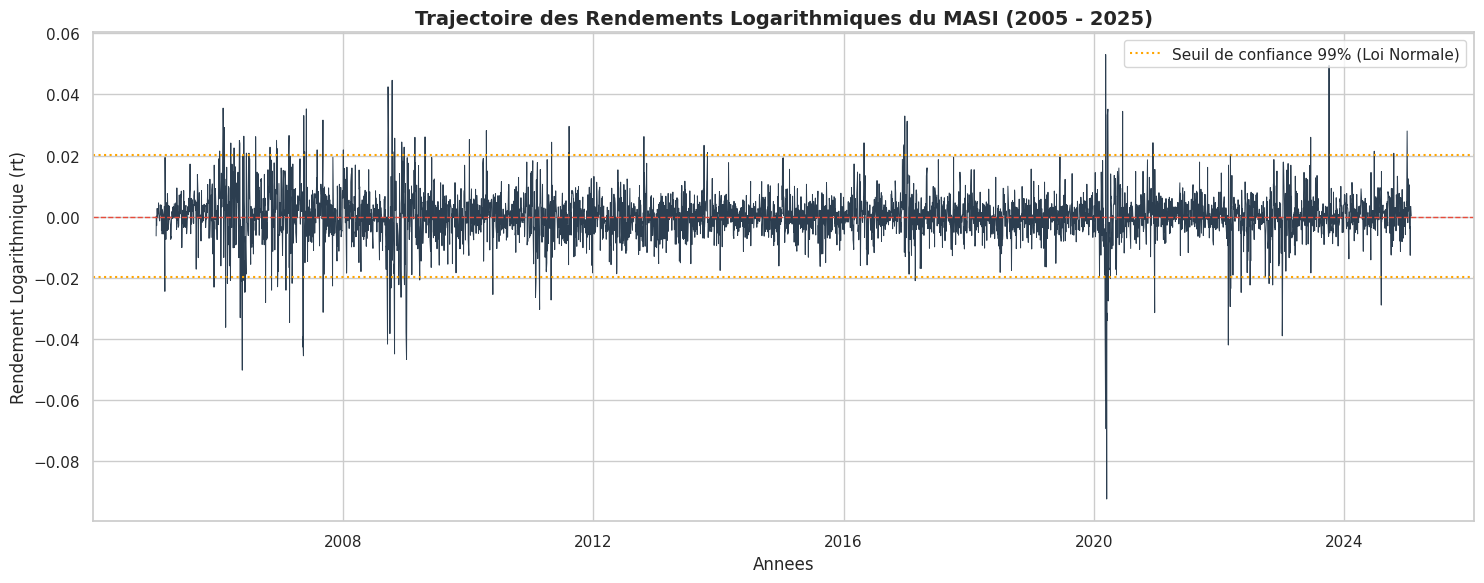

In [3]:
from scipy.stats import skew, kurtosis

print("Calcul des rendements continus en cours...")

# Calcul vectorise grace aux proprietes de Pandas (shift decale la serie d'un jour)
df_masi['log_return'] = np.log(df_masi['Close'] / df_masi['Close'].shift(1))

# La premiere ligne devient logiquement NaN (pas de jour precedent), on la retire
df_masi = df_masi.dropna(subset=['log_return'])

# Extraction de la serie sous forme de tableau Numpy pour la rapidite des calculs
rendements = df_masi['log_return'].values

# Calcul des moments statistiques fondamentaux
mu = np.mean(rendements)
sigma = np.std(rendements)
asymetrie = skew(rendements)
aplatissement = kurtosis(rendements) # L'exces de Kurtosis

print("-" * 50)
print("STATISTIQUES DES RENDEMENTS LOGARITHMIQUES (MASI)")
print("-" * 50)
print(f"Moyenne journaliere (Drift) : {mu:.6f}")
print(f"Volatilite journaliere      : {sigma:.6f}")
print(f"Asymetrie (Skewness)        : {asymetrie:.4f}")
print(f"Kurtosis (Queues epaisses)  : {aplatissement:.4f}")
print("-" * 50)
if aplatissement > 3:
    print("Alerte Quant : Le Kurtosis est tres eleve. Le marche presente des chocs extremes (Fat Tails).")
    print("Le Mouvement Brownien standard risque de sous-estimer la VaR. Le Machine Learning sera pertinent.")

# Visualisation du regime de volatilite (Clusters de volatilite)
plt.figure(figsize=(15, 6))
plt.plot(df_masi.index, df_masi['log_return'], color='#2c3e50', linewidth=0.7)
plt.axhline(0, color='#e74c3c', linestyle='--', linewidth=1)

# Mise en evidence des bornes de volatilite normale (intervalle de confiance a 99%)
plt.axhline(mu + 2.58*sigma, color='orange', linestyle=':', linewidth=1.5, label='Seuil de confiance 99% (Loi Normale)')
plt.axhline(mu - 2.58*sigma, color='orange', linestyle=':', linewidth=1.5)

plt.title('Trajectoire des Rendements Logarithmiques du MASI (2005 - 2025)', fontsize=14, fontweight='bold')
plt.xlabel('Annees', fontsize=12)
plt.ylabel('Rendement Logarithmique (rt)', fontsize=12)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

### **3. Calcul de la VaR Historique (Baseline Empirique)**

**Objectif :**
Avant de développer des modèles prédictifs complexes, nous devons établir une *Baseline* (un modèle de référence). La méthode la plus simple et la plus intuitive dans l'industrie financière est la **VaR Historique**.

**Le Concept Empirique :**
Contrairement à la simulation de Monte Carlo, la VaR historique ne fait **aucune hypothèse mathématique** sur la forme de la distribution (elle ne suppose pas que le marché est "Normal"). Elle part d'un principe purement empirique : *le futur ressemblera au passé exact*.

L'algorithme est rudimentaire mais robuste :
1. On rassemble l'historique de tous les rendements quotidiens passés.
2. On les trie du pire (krach) au meilleur (euphorie).
3. On lit simplement la valeur qui sépare les $X\%$ des pires scénarios du reste de la distribution. C'est le calcul d'un **Quantile** (ou centile).

**Formulation mathématique :**
Si l'on cherche une VaR à un niveau de confiance $\alpha$ (ex: 95%), on s'intéresse aux $1 - \alpha$ (ex: 5%) pires rendements de la distribution empirique $R$.
$$VaR_{\alpha} = - Quantile(R, 1 - \alpha)$$

*(Note : Par convention dans la gestion des risques, la VaR est exprimée comme un nombre positif représentant une perte absolue).*

Cette méthode naïve servira de mètre étalon pour évaluer la précision de nos futurs algorithmes de Machine Learning lors du Backtesting.

Calcul de la VaR Historique en cours...
--------------------------------------------------
RESULTATS : VALUE AT RISK (VaR) HISTORIQUE - BASELINE
--------------------------------------------------
VaR (95%) : 1.0660% (Dans 5% des cas, le MASI perdra au MOINS ce pourcentage en 1 jour)
VaR (99%) : 2.2231% (Dans 1% des cas, le MASI perdra au MOINS ce pourcentage en 1 jour)
--------------------------------------------------


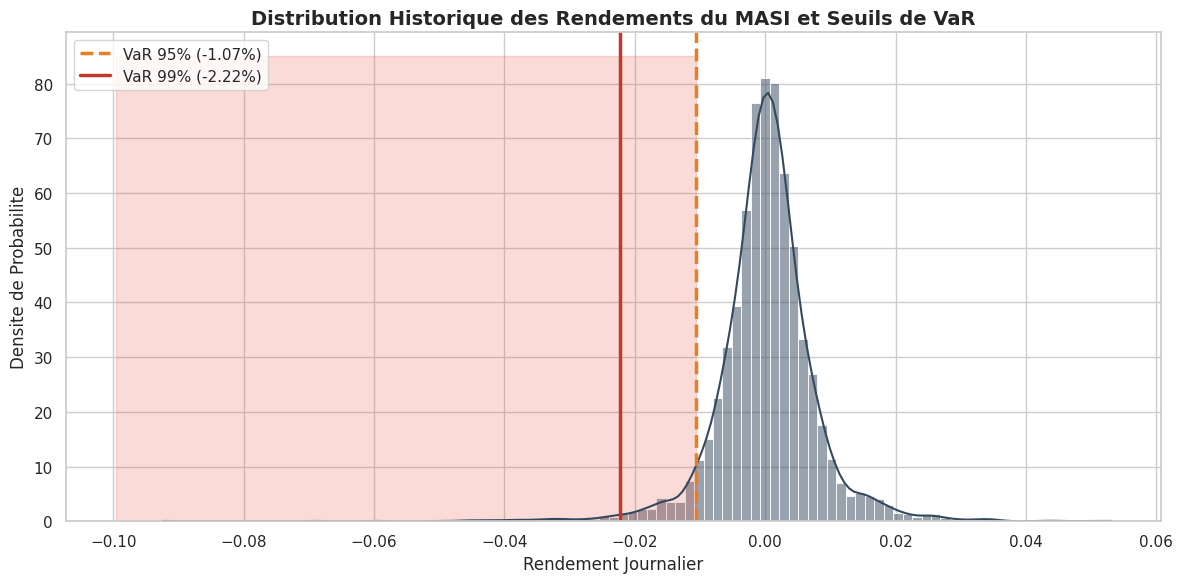

In [4]:
print("Calcul de la VaR Historique en cours...")

# Le niveau de confiance (alpha) dicte le quantile cherche
# VaR 95% -> On cherche le 5e percentile (les 5% des pires cas)
# VaR 99% -> On cherche le 1er percentile (le 1% des pires cas)
quantile_95 = np.percentile(rendements, 5)
quantile_99 = np.percentile(rendements, 1)

# Par convention, on exprime la VaR en valeur absolue (perte positive)
var_historique_95 = -quantile_95
var_historique_99 = -quantile_99

print("-" * 50)
print("RESULTATS : VALUE AT RISK (VaR) HISTORIQUE - BASELINE")
print("-" * 50)
print(f"VaR (95%) : {var_historique_95:.4%} (Dans 5% des cas, le MASI perdra au MOINS ce pourcentage en 1 jour)")
print(f"VaR (99%) : {var_historique_99:.4%} (Dans 1% des cas, le MASI perdra au MOINS ce pourcentage en 1 jour)")
print("-" * 50)

# Visualisation : La distribution empirique et les seuils de risque
plt.figure(figsize=(12, 6))

# Tracage de l'histogramme des rendements avec l'estimateur de densite (KDE)
sns.histplot(rendements, bins=100, kde=True, color='#34495e', stat='density')

# Ajout des lignes de coupe (Cut-offs) pour la VaR
plt.axvline(quantile_95, color='#e67e22', linestyle='--', linewidth=2.5,
            label=f'VaR 95% (-{var_historique_95:.2%})')
plt.axvline(quantile_99, color='#c0392b', linestyle='-', linewidth=2.5,
            label=f'VaR 99% (-{var_historique_99:.2%})')

# Remplissage de la "Queue de distribution" (Tail Risk) pour l'illustration
y_max = plt.gca().get_ylim()[1]
plt.fill_betweenx([0, y_max], plt.gca().get_xlim()[0], quantile_95, color='#e74c3c', alpha=0.2)

plt.title('Distribution Historique des Rendements du MASI et Seuils de VaR', fontsize=14, fontweight='bold')
plt.xlabel('Rendement Journalier', fontsize=12)
plt.ylabel('Densite de Probabilite', fontsize=12)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

### **4. Feature Engineering : Préparation des Signaux pour le Machine Learning**

**Objectif :**
Contrairement aux modèles stochastiques purs, les algorithmes d'apprentissage supervisé (comme les arbres de décision) ont besoin de variables explicatives ($X$) pour prédire une cible ($y$). L'objectif ici est d'extraire des caractéristiques temporelles de la série des rendements pour modéliser le comportement dynamique des investisseurs.

Nous allons créer deux grandes familles de *Features* :

**1. L'Autocorrélation (Les Rendements Décalés / Lags):**
Dans les marchés émergents ou moins liquides comme le MASI, le rendement d'aujourd'hui est souvent influencé par les jours précédents (phénomène de *momentum* ou de *mean-reversion*).
Nous créons des variables $Lag_k$ correspondant aux rendements passés :
$$Lag_k = r_{t-k}$$
*Nous utiliserons les retards de 1, 2, 3 et 5 jours (1 semaine de cotation).*

**2. La Dynamique de Marché (La Volatilité Glissante / Rolling Volatility):**
C'est le signal prédictif le plus puissant pour la VaR. La volatilité n'est pas constante. Les marchés évoluent par "régimes" (calme plat vs krach). Nous mesurons l'écart-type empirique sur des fenêtres temporelles récentes pour informer le modèle du niveau de stress actuel du marché.
$$\sigma_{t, w} = \sqrt{\frac{1}{w-1} \sum_{i=0}^{w-1} (r_{t-i} - \bar{r}_w)^2}$$
*Nous utiliserons des fenêtres $w$ de 10 jours (2 semaines), 20 jours (1 mois) et 60 jours (1 trimestre).*

**L'avantage comparatif :** Le Machine Learning pourra apprendre des règles complexes du type : *"Si la volatilité à 10 jours croise la volatilité à 60 jours à la hausse, et que le Lag 1 est très négatif, alors le risque de krach (VaR) pour demain explose."*

Creation des variables explicatives (Features)...
Nettoyage effectue : 59 lignes initiales supprimees.
Dimension du dataset final pour le ML : (4940, 14)
--------------------------------------------------


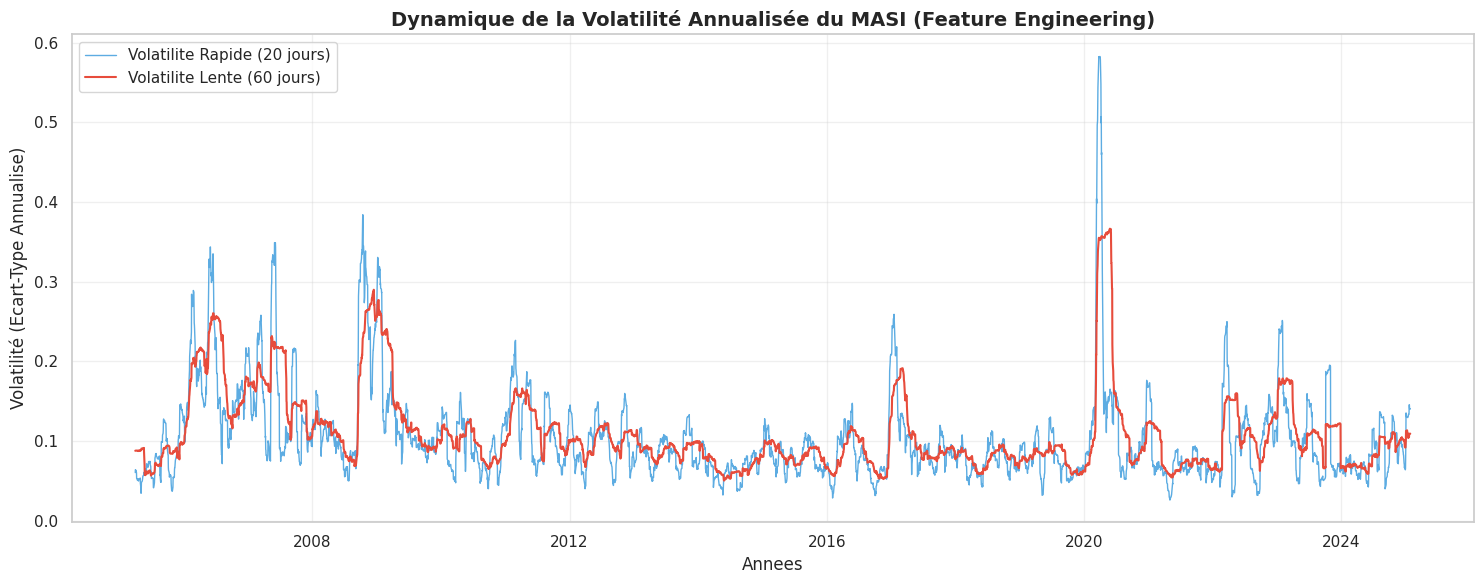

,Close,log_return,volatility_20d,volatility_60d
Date,,,,
2025-01-21,15.76892,-0.012610,0.009184,0.006886
2025-01-22,15.77563,0.000425,0.009174,0.006889
2025-01-23,15.82803,0.003316,0.008910,0.006889
2025-01-24,15.88204,0.003406,0.008817,0.006892
2025-01-27,15.88627,0.000266,0.008857,0.006895


In [5]:
print("Creation des variables explicatives (Features)...")

# 1. Creation des Lags (Rendements decales)
lags = [1, 2, 3, 5]
for lag in lags:
    df_masi[f'return_lag_{lag}'] = df_masi['log_return'].shift(lag)

# 2. Creation des Volatilites Glissantes (Rolling Volatility)
windows = [10, 20, 60]
for w in windows:
    df_masi[f'volatility_{w}d'] = df_masi['log_return'].rolling(window=w).std()

# 3. Nettoyage CIBLE du Data Leakage
# On ne cible QUE la colonne 'volatility_60d'. Ainsi, on sauvegarde nos donnees
# meme si la colonne 'Volume' brute d'Investing.com contient des erreurs.
taille_avant = len(df_masi)
df_masi = df_masi.dropna(subset=['volatility_60d'])
taille_apres = len(df_masi)

print(f"Nettoyage effectue : {taille_avant - taille_apres} lignes initiales supprimees.")
print(f"Dimension du dataset final pour le ML : {df_masi.shape}")
print("-" * 50)

# 4. Visualisation : La dynamique de la Volatilite
plt.figure(figsize=(15, 6))

# Annualisation de la volatilité (* sqrt(252))
vol_20_ann = df_masi['volatility_20d'] * np.sqrt(252)
vol_60_ann = df_masi['volatility_60d'] * np.sqrt(252)

plt.plot(df_masi.index, vol_20_ann, color='#3498db', linewidth=1, label='Volatilite Rapide (20 jours)', alpha=0.8)
plt.plot(df_masi.index, vol_60_ann, color='#e74c3c', linewidth=1.5, label='Volatilite Lente (60 jours)')

plt.title('Dynamique de la Volatilité Annualisée du MASI (Feature Engineering)', fontsize=14, fontweight='bold')
plt.xlabel('Annees', fontsize=12)
plt.ylabel('Volatilité (Ecart-Type Annualise)', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Verification visuelle des dernieres colonnes creees
display(df_masi[['Close', 'log_return', 'volatility_20d', 'volatility_60d']].tail())

### **5. Séparation Temporelle (Data Splitting) et Prévention du Data Leakage**

**Objectif :**
Diviser notre jeu de données pour l'entraînement, l'ajustement et l'évaluation finale de nos modèles.

**Le Piège du "Data Leakage" (Fuite de données) :**
Dans les problèmes d'apprentissage automatique classiques, la norme est d'utiliser un mélange aléatoire (`shuffle=True`). En modélisation de séries temporelles financières, **le mélange aléatoire est strictement interdit**.
Si l'on mélange les dates, le modèle pourrait utiliser le rendement de demain (qui se retrouverait par erreur dans le set d'entraînement) pour prédire le rendement d'aujourd'hui. C'est ce qu'on appelle un biais de "voyage dans le temps" (Look-ahead bias).

Pour garantir un Backtesting scientifique (Out-of-sample), nous devons effectuer un **découpage chronologique strict** :

1. **Set d'Entraînement / Train (2005 - 2017) :** L'échantillon historique profond. Il contient des périodes de croissance et la crise des Subprimes (2008). Il servira à calibrer le modèle de Monte Carlo et à entraîner les arbres de décision.
2. **Set de Validation / Val (2018 - 2019) :** Une période de deux ans, relativement calme, utilisée exclusivement pour le Machine Learning. Elle permet d'ajuster les hyperparamètres (GridSearch) et de stopper l'entraînement avant le surapprentissage (*Early Stopping*).
3. **Set de Test / Test (2020 - 2025) :** Le juge de paix (Out-of-sample). Ces données sont totalement cachées aux algorithmes pendant leur conception. Cette période contient le krach brutal du COVID-19 et la forte inflation. C'est sur ce segment que nous compterons les "Violations de la VaR" pour comparer Monte Carlo et Machine Learning.

Decoupage temporel du dataset en cours...
--------------------------------------------------
DIMENSIONS DES DATASETS
--------------------------------------------------
Train Set      (2005-2017) : 3182 jours (64.4%)
Validation Set (2018-2019) : 493 jours (10.0%)
Test Set       (2020-2025) : 1265 jours (25.6%)
--------------------------------------------------


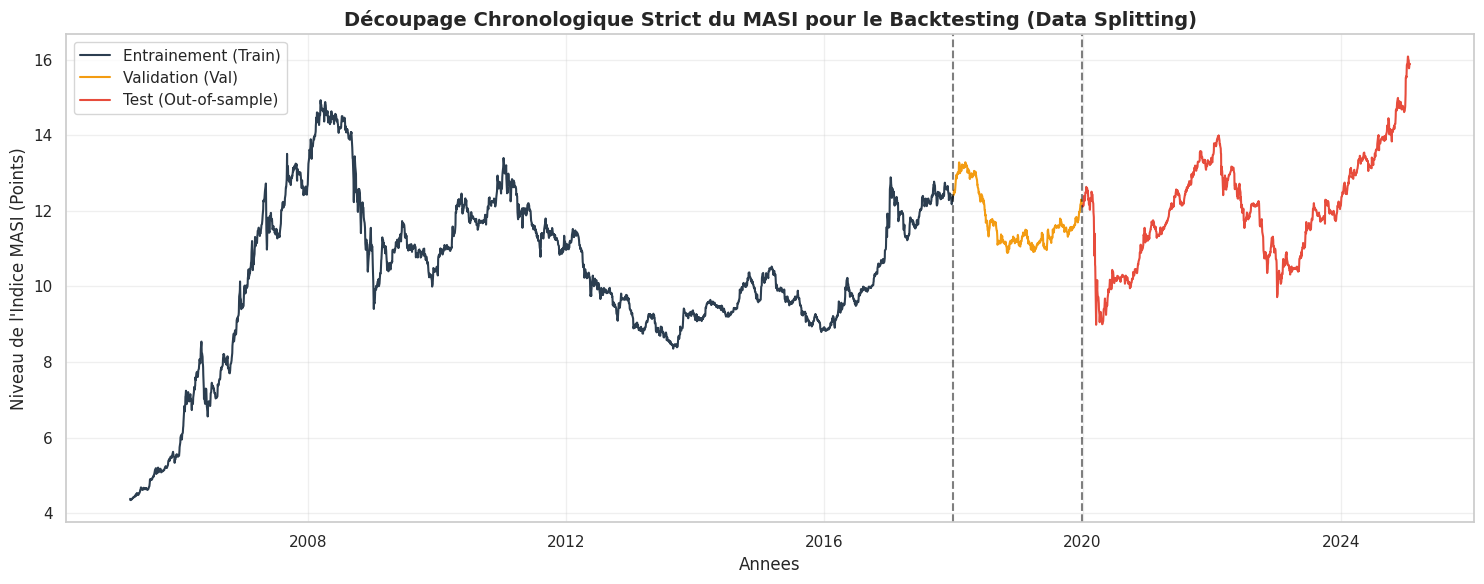

 SUCCES : Les datasets nettoyes et decoupes ont ete sauvegardes en format CSV.


In [6]:
print("Decoupage temporel du dataset en cours...")

# Decoupage strict base sur l'index temporel (sans aucun melange/shuffle)
train_data = df_masi.loc['2005-01-01':'2017-12-31']
val_data   = df_masi.loc['2018-01-01':'2019-12-31']
test_data  = df_masi.loc['2020-01-01':'2025-12-31']

print("-" * 50)
print("DIMENSIONS DES DATASETS")
print("-" * 50)
print(f"Train Set      (2005-2017) : {train_data.shape[0]} jours ({len(train_data)/len(df_masi):.1%})")
print(f"Validation Set (2018-2019) : {val_data.shape[0]} jours ({len(val_data)/len(df_masi):.1%})")
print(f"Test Set       (2020-2025) : {test_data.shape[0]} jours ({len(test_data)/len(df_masi):.1%})")
print("-" * 50)

# Visualisation professionnelle du decoupage (Sur le prix de cloture pour plus de clarte)
plt.figure(figsize=(15, 6))

plt.plot(train_data.index, train_data['Close'], color='#2c3e50', linewidth=1.5, label='Entrainement (Train)')
plt.plot(val_data.index, val_data['Close'], color='#f39c12', linewidth=1.5, label='Validation (Val)')
plt.plot(test_data.index, test_data['Close'], color='#e74c3c', linewidth=1.5, label='Test (Out-of-sample)')

# Lignes de separation verticales
plt.axvline(pd.to_datetime('2017-12-31'), color='black', linestyle='--', alpha=0.5)
plt.axvline(pd.to_datetime('2019-12-31'), color='black', linestyle='--', alpha=0.5)

plt.title('Découpage Chronologique Strict du MASI pour le Backtesting (Data Splitting)', fontsize=14, fontweight='bold')
plt.xlabel('Annees', fontsize=12)
plt.ylabel('Niveau de l\'Indice MASI (Points)', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ETAPE FINALE : SAUVEGARDE SUR LE DISQUE
# Ces fichiers seront les points d'entree exclusifs des prochains notebooks.
train_data.to_csv('masi_train_clean.csv')
val_data.to_csv('masi_val_clean.csv')
test_data.to_csv('masi_test_clean.csv')
df_masi.to_csv('masi_full_clean.csv') # Sauvegarde du dataset complet nettoye

print(" SUCCES : Les datasets nettoyes et decoupes ont ete sauvegardes en format CSV.")